In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from ipywidgets import interactive, FloatSlider, IntSlider, VBox, HBox, Output
import ipywidgets as widgets


# Linearity, Time Invariance, Causality, Anti-Causality, and BIBO Stability

Revising LTI: https://ringbuffer.org/dsp/Signals_and_Operations/lti_systems/

1. **Linearity**: The system satisfies superposition.  
2. **Time Invariance**: Shifting the input signal in time simply shifts the output by the same amount.  
3. **Causality**: A causal system depends on the current and past inputs (cannot use future inputs in real-time).  
4. **Anti-Causality**: An anti-causal system depends on future inputs (not physically realizable in real-time).


5. **BIBO Stability**: An LTI system is stable if and only if its impulse response is absolutely summable (converges).

## Stability in a Feedback system

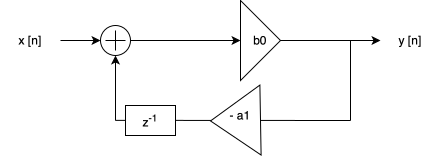

In [1]:
from IPython import display 
display.display(display.SVG(filename="flowFeedback.svg"))


In [2]:
def iir_filter_direct(x, b, a):

    N = len(x)
    M = len(b)
    P = len(a)
    y = np.zeros(N)
    
    for n in range(N):
        # Feedforward part
        for k in range(M):
            if n - k >= 0:
                y[n] += b[k] * x[n - k]
        
        # Feedback part
        for k in range(1, P):
            if n - k >= 0:
                y[n] -= a[k] * y[n - k]
        
        y[n] /= a[0]
    
    return y


@interact(alpha=FloatSlider(min=-1.5, max=1.5, step=0.01, value=0.9, description='a - feedback coefficient'))
def plot_iir_impulse_response(alpha):
    # Create an impulse of length N
    N = 50
    x = np.zeros(N)
    x[0] = 1.0  # impulse at n=0

    # Define filter coefficients for y[n] = alpha*y[n-1] + x[n]
    b = [1.0]        # feedforward
    a = [1.0, alpha]  # feedback

    # Filter the impulse
    y = iir_filter_direct(x, b, a)
    
    # Plot
    plt.figure(figsize=(7, 3))
    plt.stem(y, basefmt=" ")
    plt.title(f"IIR Filter Response to Impulse (a = {alpha:.2f})")
    plt.xlabel("n")
    plt.ylabel("y[n]")
    plt.ylim([-2, 4])  # adjust if needed to see blow-up
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.show()
    
    if abs(alpha) >= 1.0:
        print("System is UNSTABLE for |alpha| >= 1 -> output can blow up!")
    else:
        print("System is STABLE for |alpha| < 1 -> output decays over time.")


interactive(children=(FloatSlider(value=0.9, description='a - feedback coefficient', max=1.5, min=-1.5, step=0…

## Phase

## Time Shift Property (DFT / Frequency Bins) Revisited

In an $N$-point DFT (Discrete Fourier Transform), the frequency-domain samples occur at

$$
\omega_k = \frac{2\pi k}{N}, \quad k = 0,1,\dots,N-1.
$$

If the signal is delayed by n_0 samples, then

$$
y[n] = x[n - n_0],
$$

then the DFT of $y[n]$, denoted $Y[k]$, relates to the DFT of $x[n]$ (denoted $X[k]$) by

$$
Y[k] = e^{-\,j\,\frac{2\pi k}{N}\,n_0}\; X[k].
$$

At the $k$-th DFT bin, the phase shift is

$$
-\;\frac{2\pi}{N}\,k\,n_0.
$$

As $k$ increases, this phase shift grows proportionally. Thus, higher-frequency bins get a larger phase rotation.


In [5]:
from ipywidgets import interact, IntSlider

fs = 10000
def single_cycle_sine(frequency, fs):
    T = 1.0 / frequency           # Period (seconds)
    N = int(np.round(fs * T))     # Number of samples in one period
    t = np.linspace(0, 1, fs, endpoint=False)
    x = np.sin(2 * np.pi * frequency * t)
    return N, x

# Frequencies
f1, f2, f3 = 50, 100, 150  # Hz
t = np.linspace(0, 1, fs, endpoint=False)
# Generate one cycle of each
N1, x1 = single_cycle_sine(f1, fs)
N2, x2 = single_cycle_sine(f2, fs)
N3, x3 = single_cycle_sine(f3, fs)

x_sum = x1+x2+x3
N = fs
# Compute references for each original sinusoid in the DFT domain
X1 = np.fft.fft(x1, N)
X2 = np.fft.fft(x2, N)
X3 = np.fft.fft(x3, N)

# Helper: map frequency -> nearest DFT bin
def freq_bin_index(freq, fs, N):
    return int(round(freq * N / fs))

k1 = freq_bin_index(f1, fs, N)
k2 = freq_bin_index(f2, fs, N)
k3 = freq_bin_index(f3, fs, N)

@interact(delay=IntSlider(min=0, max=200, step=1, value=10, description='Delay (samples)'))
def show_delayed_phase(delay):

    # 1) Create delayed versions by rolling the array
    y1 = np.roll(x1, delay)
    y2 = np.roll(x2, delay)
    y3 = np.roll(x3, delay)
    ysum = y1+y2+y3

    # 2) Compute FFT of delayed signals
    Y1 = np.fft.fft(y1, N)
    Y2 = np.fft.fft(y2, N)
    Y3 = np.fft.fft(y3, N)

    # 3) Phase difference (angle(Y) - angle(X)) at each frequency bin
    pd1 = np.angle(Y1[k1]) - np.angle(X1[k1])  # radians
    pd2 = np.angle(Y2[k2]) - np.angle(X2[k2])  # radians
    pd3 = np.angle(Y3[k3]) - np.angle(X3[k3])  # radians

    # Convert to degrees
    pd1_deg = np.degrees(pd1)
    pd2_deg = np.degrees(pd2)
    pd3_deg = np.degrees(pd3)

    # --- Plot each sinusoid in its own subplot ---
    fig, axes = plt.subplots(4, 1, figsize=(8, 7), sharex=True)

    # Plot for f1
    axes[0].plot(t[:N1], ysum[:N1], label=f'Delayed by {delay}')
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Sum Sinusoid")
    axes[0].legend(loc='best')
    axes[0].grid(True)

    #axes[1].plot(t, x1, label=f'Original {f1} Hz')
    axes[1].plot(t[:N1], y1[:N1], label=f'Delayed by {delay}')
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"{f1} Hz Sinusoid")
    axes[1].legend(loc='best')
    axes[1].grid(True)

    # Plot for f2
    #axes[1].plot(t, x2, label=f'Original {f2} Hz')
    axes[2].plot(t[:N2], y2[:N2], label=f'Delayed by {delay}')
    axes[2].set_ylabel("Amplitude")
    axes[2].set_title(f"{f2} Hz Sinusoid")
    axes[2].legend(loc='best')
    axes[2].grid(True)

    # Plot for f3
    #axes[2].plot(t, x3, label=f'Original {f3} Hz')
    axes[3].plot(t[:N3], y3[:N3], label=f'Delayed by {delay}')
    axes[3].set_ylabel("Amplitude")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_title(f"{f3} Hz Sinusoid")
    axes[3].legend(loc='best')
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    # 4) Print summary of phase shifts
    print(f"Delay = {delay} samples")
    print(f"Frequency {f1} Hz -> Phase Shift ≈ {pd1_deg:.2f}°")
    print(f"Frequency {f2} Hz -> Phase Shift ≈ {pd2_deg:.2f}°")
    print(f"Frequency {f3} Hz -> Phase Shift ≈ {pd3_deg:.2f}°")


interactive(children=(IntSlider(value=10, description='Delay (samples)', max=200), Output()), _dom_classes=('w…

## Does phase matter?

Since a pure **time delay** (or any all-pass transformation) does **not** alter the **magnitude spectrum**, the *perceived* sound is unchanged—**if** we only consider steady-state tones in isolation. Human hearing is often considered **“phase-invariant”** in the sense that **global** or **absolute** phase shifts do not change the *pitch* or *timbre* of continuous, steady-state sounds. 

However, **phase** can still matter in practical scenarios:

1. **Transients and Attack**  
   - Our ears are sensitive to **time-domain cues**, especially **transients** (onsets of notes, percussive hits).  
   - A large or frequency-dependent phase shift can smear or realign partials differently in the *attack* portion, potentially altering the perceived *sharpness* or *character* of a sound.

2. **Localization** (Binaural Hearing)  
   - The human auditory system uses **phase and time differences** between the left and right ears to localize sound sources.  
   - Absolute phase shifts in a *monophonic* signal often do not matter, but **relative** phase shifts between multiple signals (e.g., stereo channels or separate sources) can profoundly affect stereo imaging and localization.

3. **Comb Filtering** and Interference  
   - When two copies of the same signal are combined with a delay (phase difference), you get **constructive and destructive interference**. This *does* modify the magnitude spectrum at certain frequencies (a “comb filter” effect). So even “just a delay” in a multi-source context can change what you hear.




### Some audio examples as illustrated by Brian Mcfee: https://brianmcfee.net/dstbook-site/content/ch10-convtheorem/Phase.html

In [6]:
import IPython.display as ipd
from scipy.io import wavfile
def load_audio_signal(path):

    # Read the WAV file
    fs, data = wavfile.read(path)
    
    # If stereo, convert to mono by averaging channels
    if data.ndim > 1:
        data = data.mean(axis=1)
    
    # Optionally, normalize the signal to range [-1, 1] if the dtype is integer
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data / max_val
    
    return data, fs

### Drums

In [7]:
audio,fs = load_audio_signal("drum_beat.wav")

/var/folders/td/wr0v_l5j16bgp1cvydp7pmqc0000gn/T/ipykernel_99224/1433471612.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(path)


In [8]:
ipd.Audio(audio, rate=fs)

### Discarding Phase

In [9]:
# Take the DFT
X = np.fft.rfft(audio)

# Discard phase
Y = np.abs(X)

# Invert the DFT
y = np.fft.irfft(Y)

In [10]:
ipd.Audio(y, rate=fs)

### Visualizing The Spectrum

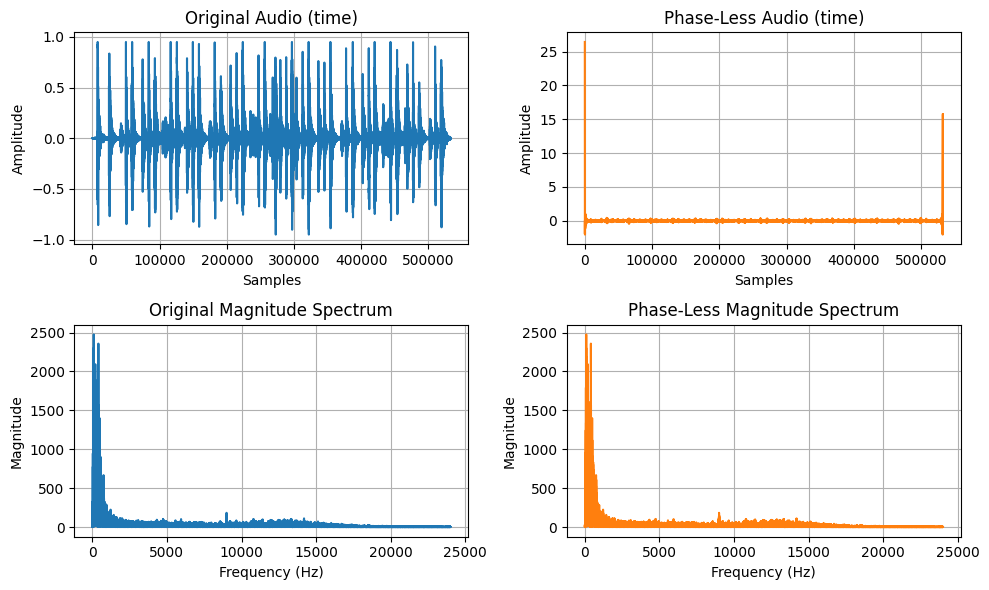

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fs = 48000
N = len(audio)

#Compute FFT of the original audio (real FFT for a real signal)
X = np.fft.rfft(audio)

#Discard phase -> keep only magnitudes
X_mag = np.abs(X)

# Invert the FFT to reconstruct a phase-less time-domain signal
audio_phase_less = np.fft.irfft(X_mag)

# Compute FFT of the phase-less signal for comparison
Y = np.fft.rfft(audio_phase_less)
Y_mag = np.abs(Y)

# Build a frequency axis (0 to Nyquist) for plotting
freqs = np.fft.rfftfreq(N, 1.0/fs)


fig, axes = plt.subplots(2, 2, figsize=(10, 6))


axes[0,0].plot(audio, color='C0')
axes[0,0].set_title("Original Audio (time)")
axes[0,0].set_xlabel("Samples")
axes[0,0].set_ylabel("Amplitude")
axes[0,0].grid(True)


axes[0,1].plot(audio_phase_less, color='C1')
axes[0,1].set_title("Phase-Less Audio (time)")
axes[0,1].set_xlabel("Samples")
axes[0,1].set_ylabel("Amplitude")
axes[0,1].grid(True)


axes[1,0].plot(freqs, X_mag, color='C0')
axes[1,0].set_title("Original Magnitude Spectrum")
axes[1,0].set_xlabel("Frequency (Hz)")
axes[1,0].set_ylabel("Magnitude")
axes[1,0].grid(True)


axes[1,1].plot(freqs, Y_mag, color='C1')
axes[1,1].set_title("Phase-Less Magnitude Spectrum")
axes[1,1].set_xlabel("Frequency (Hz)")
axes[1,1].set_ylabel("Magnitude")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

### Same experiment with a stable tone

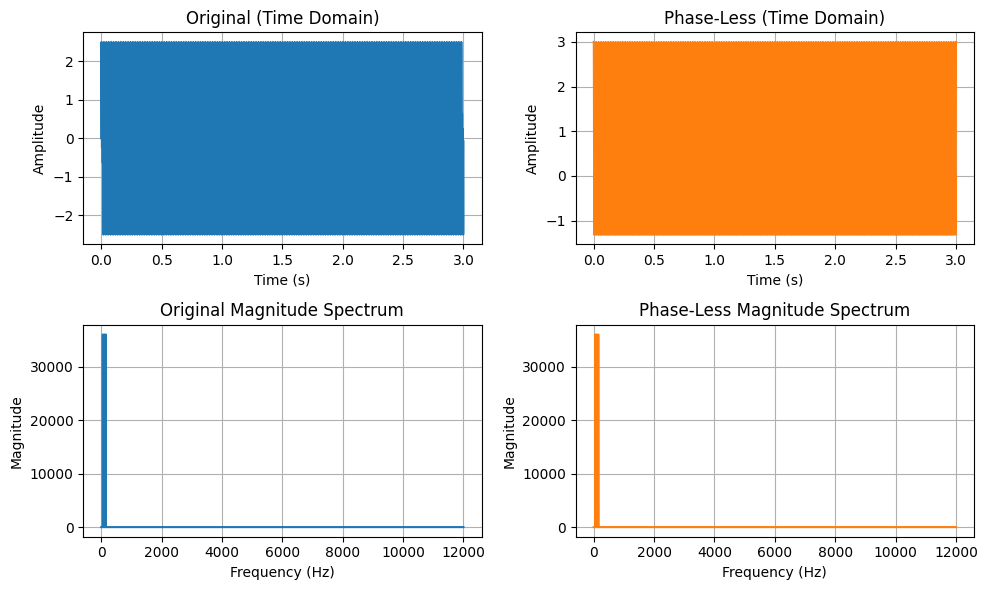

In [12]:
import numpy as np
import matplotlib.pyplot as plt


fs = 24000   
duration = 3
t = np.linspace(0, duration, int(fs*duration), endpoint=False)

f1, f2, f3 = 50, 100, 150  # Hz
x1 = np.sin(2*np.pi * f1 * t)
x2 = np.sin(2*np.pi * f2 * t)
x3 = np.sin(2*np.pi * f3 * t)

audio = x1 + x2 + x3  
N = len(audio)


X = np.fft.rfft(audio)       
X_mag = np.abs(X)    


audio_phase_less = np.fft.irfft(X_mag)


Y = np.fft.rfft(audio_phase_less)
Y_mag = np.abs(Y)



freqs = np.fft.rfftfreq(N, 1.0/fs)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# (Row 1, Col 1): Original time-domain waveform
axes[0,0].plot(t, audio, color='C0')
axes[0,0].set_title("Original (Time Domain)")
axes[0,0].set_xlabel("Time (s)")
axes[0,0].set_ylabel("Amplitude")
axes[0,0].grid(True)

# (Row 1, Col 2): Phase-less time-domain waveform
axes[0,1].plot(t, audio_phase_less, color='C1')
axes[0,1].set_title("Phase-Less (Time Domain)")
axes[0,1].set_xlabel("Time (s)")
axes[0,1].set_ylabel("Amplitude")
axes[0,1].grid(True)

# (Row 2, Col 1): Original magnitude spectrum
axes[1,0].plot(freqs, X_mag, color='C0')
axes[1,0].set_title("Original Magnitude Spectrum")
axes[1,0].set_xlabel("Frequency (Hz)")
axes[1,0].set_ylabel("Magnitude")
axes[1,0].grid(True)

# (Row 2, Col 2): Phase-Less magnitude spectrum
axes[1,1].plot(freqs, Y_mag, color='C1')
axes[1,1].set_title("Phase-Less Magnitude Spectrum")
axes[1,1].set_xlabel("Frequency (Hz)")
axes[1,1].set_ylabel("Magnitude")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


In [13]:
ipd.Audio(audio, rate=24000)

In [14]:
ipd.Audio(audio_phase_less, rate=24000)

# Group Delay and Its Relationship to Phase Response

## Definition of Group Delay

The **group delay** of a system is defined as the **negative derivative of the phase response** with respect to angular frequency ($\omega$):

$$
\tau_{\text{group}}(\omega) = -\frac{d \phi(\omega)}{d \omega}
$$

where:
- $ \phi(\omega) $ is the **phase response** of the system.
- $ \omega = 2\pi f $ is the **angular frequency** in radians per second.

---

## Intuition

- **Group delay** measures **how much time** a narrowband signal **centered at frequency $ \omega $** is delayed by the system.
- It is **not always constant**—in dispersive systems (e.g., certain IIR filters), different frequencies experience different delays.
- When the **phase response is linear** ($ \phi(\omega) = -D \omega $), the group delay is **constant** and equals $D$, meaning all frequencies are delayed equally.

---

## Relationship to Phase Response

A system's **group delay** can be directly computed from its **phase response**:

1. Compute the **phase response** $ \phi(\omega) $.
2. Take its **derivative** with respect to $ \omega $.
3. Negate the result to get $ \tau_{\text{group}}(\omega) $.

Example:
- If $ \phi(\omega) = -D \omega $, then

  $$
  \tau_{\text{group}}(\omega) = -\frac{d}{d\omega}(-D\omega) = D
  $$

  meaning the delay is constant for all frequencies.

- If $ \phi(\omega) $ is **nonlinear**, different frequencies will experience **different delays**, which can cause signal distortion.


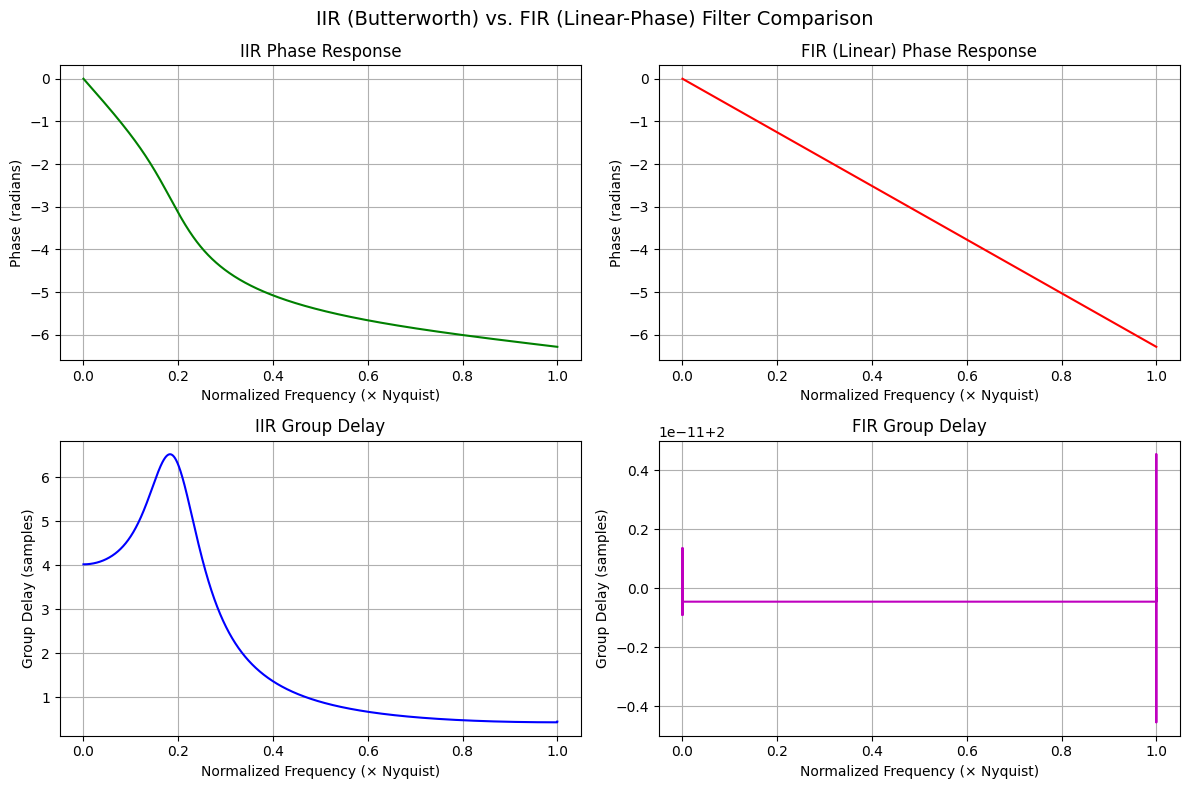

In [15]:
from scipy.signal import freqz, butter, firwin


#IIR Butterworth Filter (Nonlinear Phase)
order_iir = 4
cutoff = 0.2 
b_iir, a_iir = butter(order_iir, cutoff, btype='low', analog=False)


w_iir, h_iir = freqz(b_iir, a_iir, worN=8192)
phase_iir = np.unwrap(np.angle(h_iir))

# Compute group delay (negative derivative of phase wrt. w)
group_delay_iir = -np.gradient(phase_iir, w_iir)


#FIR Linear-Phase Filter
order_fir = 4
b_fir = firwin(order_fir + 1, cutoff, window='hamming', pass_zero=True)
a_fir = [1.0] 

# Same frequency resolution
w_fir, h_fir = freqz(b_fir, a_fir, worN=8192)
phase_fir = np.unwrap(np.angle(h_fir))

group_delay_fir = -np.gradient(phase_fir, w_fir)



fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("IIR (Butterworth) vs. FIR (Linear-Phase) Filter Comparison", fontsize=14)


axes[0,0].plot(w_iir/np.pi, phase_iir, color='g')
axes[0,0].set_title("IIR Phase Response")
axes[0,0].set_xlabel("Normalized Frequency (× Nyquist)")
axes[0,0].set_ylabel("Phase (radians)")
axes[0,0].grid(True)


axes[0,1].plot(w_fir/np.pi, phase_fir, color='r')
axes[0,1].set_title("FIR (Linear) Phase Response")
axes[0,1].set_xlabel("Normalized Frequency (× Nyquist)")
axes[0,1].set_ylabel("Phase (radians)")
axes[0,1].grid(True)


axes[1,0].plot(w_iir/np.pi, group_delay_iir, color='b')
axes[1,0].set_title("IIR Group Delay")
axes[1,0].set_xlabel("Normalized Frequency (× Nyquist)")
axes[1,0].set_ylabel("Group Delay (samples)")
axes[1,0].grid(True)

axes[1,1].plot(np.round(w_fir/np.pi), group_delay_fir, color='m')
axes[1,1].set_title("FIR Group Delay")
axes[1,1].set_xlabel("Normalized Frequency (× Nyquist)")
axes[1,1].set_ylabel("Group Delay (samples)")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()
